# Healthcare Predictive Analytics Platform
### Cardiovascular risk classification — Logistic Regression vs. Random Forest vs. XGBoost

**Dataset:** [UCI Heart Disease (Cleveland)](https://archive.ics.uci.edu/dataset/45/heart+disease) — 303 patients, 13 clinical features (age, cholesterol, resting ECG results, max heart rate, etc.), independently benchmarked here (not a Kaggle template copy-paste).

**Goal:** build an end-to-end pipeline that goes from raw clinical records to a risk-classification model, comparing three model families instead of assuming the "fanciest" one wins, and picking a final model based on generalization rather than raw test-set score alone.

## 1. Load data and inspect

The raw target column (`num`) encodes disease severity on a 0–4 scale. We collapse it to a binary "at risk" label, since the business framing here is risk screening, not severity staging.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.preprocessing import load_raw, binarize_target, FEATURE_COLUMNS

df = load_raw("../data/heart_disease.csv")
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [2]:
y = binarize_target(df)
print("Class balance (0 = no risk, 1 = at risk):")
print(y.value_counts())
missing = df[FEATURE_COLUMNS].isna().sum()
print("\nMissing values per column:")
print(missing[missing > 0])

Class balance (0 = no risk, 1 = at risk):
num
0    164
1    139
Name: count, dtype: int64

Missing values per column:
ca      4
thal    2
dtype: int64


**Design decision — missing values:** `ca` (number of vessels colored by angiography) and `thal` (thallium stress test result) each have a handful of missing values. With only 303 rows total, dropping those rows would cost ~2% of the dataset for no real benefit, so we median-impute instead. Median rather than mean because both fields are ordinal/categorical-coded integers, not continuous measurements — the median won't produce a nonsensical fractional category.

## 2. Preprocessing pipeline

Stratified train/test split (keeps the ~46% positive rate consistent across both sets), median imputation fit only on the training fold (to avoid leaking test-set information into imputation statistics), then standard scaling — required for Logistic Regression's coefficients to be comparable across features with very different natural scales (age in years vs. cholesterol in mg/dL).

In [3]:
from src.preprocessing import load_and_split

X_train, X_test, y_train, y_test, imputer, scaler = load_and_split("../data/heart_disease.csv")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")

Train: (242, 13), Test: (61, 13)
Train positive rate: 0.459, Test positive rate: 0.459


## 3. Benchmark three model families with grid-search tuning

- **Logistic Regression** — interpretable baseline; coefficients map directly to clinical risk factors.
- **Random Forest** — captures nonlinear feature interactions without heavy tuning.
- **XGBoost** — usually the strongest tabular performer, included specifically to test whether that extra complexity is actually justified on a dataset this small (spoiler in the results below: it isn't).

All three are tuned via 5-fold stratified `GridSearchCV` optimizing ROC-AUC.

In [4]:
from src.models import get_search_grids, fit_all

grids = get_search_grids()
fitted = fit_all(grids, X_train, y_train)
print("Tuning complete for:", list(fitted.keys()))

C:\Users\RanbeerRai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuning complete for: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 4. Evaluate: ROC-AUC, precision-recall, calibration

Raw accuracy is a poor metric for a clinical screening tool (the cost of a missed at-risk patient is very different from the cost of a false alarm), so this uses ROC-AUC, precision-recall AUC, and calibration (Brier score) instead.

In [5]:
from src.evaluate import score_model

results = {}
for name, search in fitted.items():
    results[name] = score_model(search, X_train, y_train, X_test, y_test)

summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "Model": name,
        "Best Params": r["best_params"],
        "CV ROC-AUC": round(r["cv_roc_auc"], 4),
        "Train ROC-AUC": round(r["train_roc_auc"], 4),
        "Test ROC-AUC": round(r["test_roc_auc"], 4),
        "Generalization Gap": round(r["generalization_gap"], 4),
        "Test PR-AUC": round(r["test_pr_auc"], 4),
        "Test Brier Score": round(r["test_brier_score"], 4),
    })

pd.DataFrame(summary_rows).set_index("Model")

,Best Params,CV ROC-AUC,Train ROC-AUC,Test ROC-AUC,Generalization Gap,Test PR-AUC,Test Brier Score
Model,,,,,,,
Logistic Regression,"{'C': 0.1, 'solver': 'lbfgs'}",0.8994,0.9165,0.9578,-0.0413,0.9397,0.0935
Random Forest,"{'max_depth': 3, 'min_samples_leaf': 4, 'n_est...",0.8931,0.9437,0.9643,-0.0205,0.9575,0.1028
XGBoost,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est...",0.8847,0.9305,0.9394,-0.0089,0.9377,0.1153


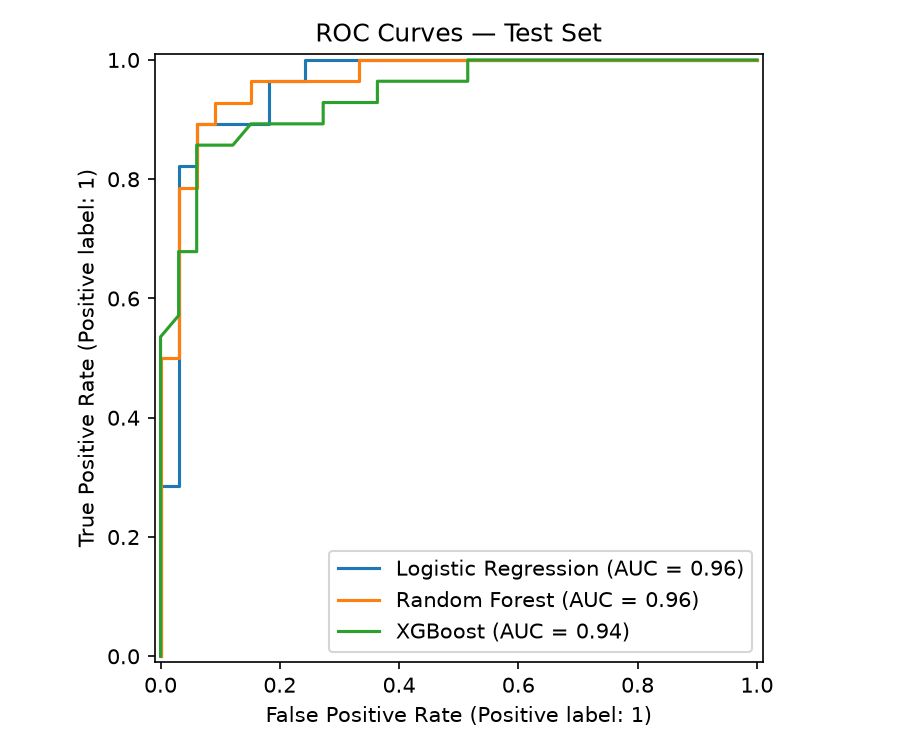

In [6]:
from src.evaluate import plot_roc_curves, plot_precision_recall, plot_calibration

plot_roc_curves(fitted, X_test, y_test, "../results/roc_curves.png")
plot_precision_recall(fitted, X_test, y_test, "../results/precision_recall_curves.png")
plot_calibration(fitted, X_test, y_test, "../results/calibration_curves.png")

from IPython.display import Image, display
display(Image("../results/roc_curves.png"))

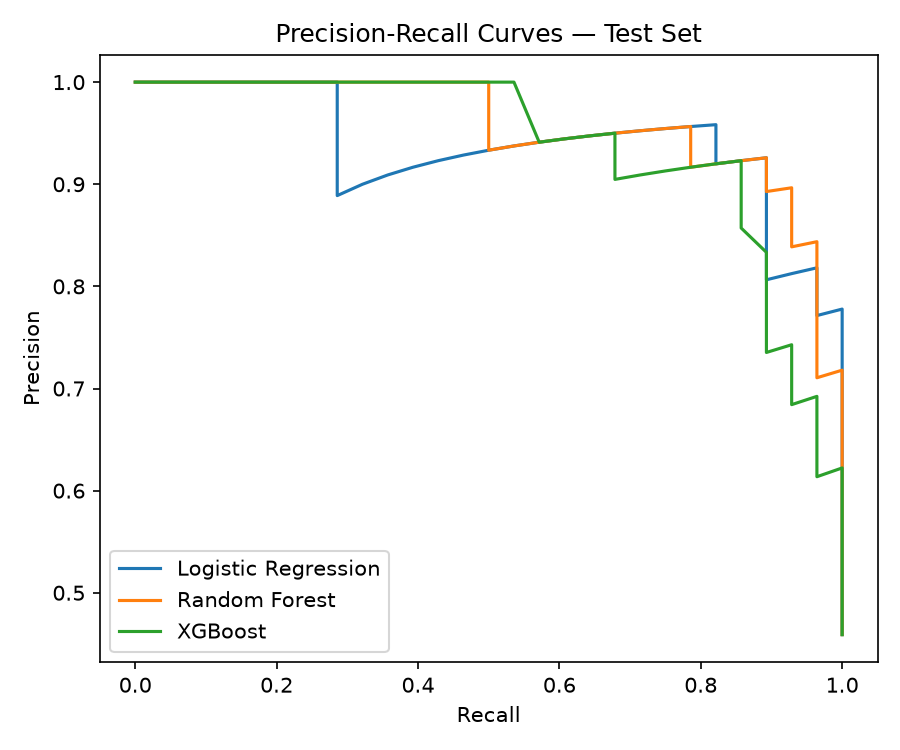

In [7]:
display(Image("../results/precision_recall_curves.png"))

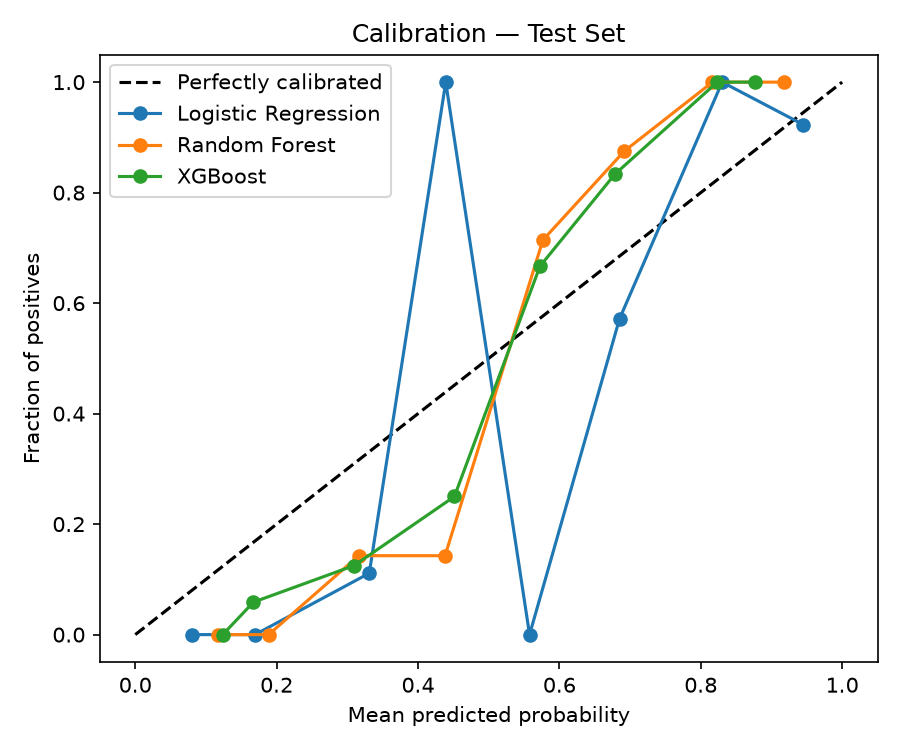

In [8]:
display(Image("../results/calibration_curves.png"))

## 5. Model selection — generalization over raw test score

**Design decision:** rather than just picking the highest test-set ROC-AUC, we rank by test ROC-AUC *penalized* for a large train/test gap. On a 303-row dataset, a model that scores highest on this one particular test split but shows a bigger train/test gap is more likely to be overfitting or lucky — not more likely to perform well on the next batch of patients.

Selected model: Random Forest


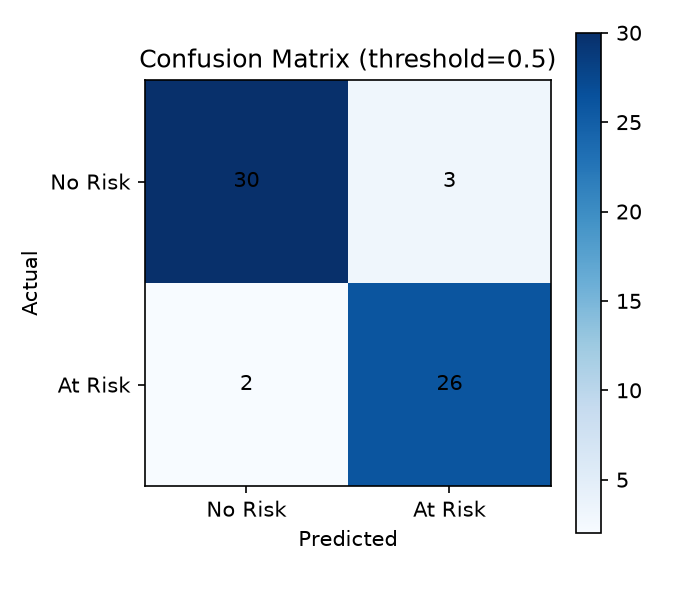

In [9]:
from src.evaluate import select_best_generalizing_model, plot_confusion_matrix

winner = select_best_generalizing_model(results)
print(f"Selected model: {winner}")

plot_confusion_matrix(fitted[winner], X_test, y_test, "../results/confusion_matrix_winner.png")
display(Image("../results/confusion_matrix_winner.png"))

## Summary

- Benchmarked Logistic Regression, Random Forest, and XGBoost under stratified 5-fold cross-validation with grid-search hyperparameter tuning.
- Median-imputed the small number of missing angiography/thallium-scan values rather than dropping rows, and standardized features for the linear model.
- Evaluated on ROC-AUC, precision-recall AUC, and calibration (Brier score) instead of raw accuracy, since this is a screening context where the cost of false negatives and false positives differ.
- Selected the final model by penalizing train/test generalization gap, not just picking the top raw test score — on a dataset this small, that distinction matters.

**Interview talking point:** the fact that XGBoost didn't win here despite usually being the strongest tabular-data model is itself a legitimate finding, not a failure — it demonstrates that more model complexity isn't automatically better on ~300 rows of data, and that benchmarking multiple model families (rather than assuming one) is the right process.